# Descriptive Figures — Trump Tweets vs S&P 500 & VIX

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

os.chdir(os.path.join(os.path.dirname(os.getcwd()), 'trump_vs_stock_market') if 'scripts' not in os.getcwd() else os.path.join(os.getcwd(), '..'))

SAVE_DIR = "images/descriptive"
os.makedirs(SAVE_DIR, exist_ok=True)

## Load data

In [2]:
tweets = pd.read_csv("data/trump_tweets.csv", parse_dates=["date", "datetime"])

stock = pd.read_csv("data/stock_market.csv", skiprows=[1, 2])
stock.rename(columns={"Price": "date"}, inplace=True)
stock["date"] = pd.to_datetime(stock["date"])
stock.set_index("date", inplace=True)
stock.columns = ["SP500_Close", "VIX_Close"]
stock = stock.apply(pd.to_numeric, errors="coerce")

daily_tweets = (
    tweets.groupby("date")
    .agg(n_tweets=("id", "count"))
    .reset_index()
)
daily_tweets["date"] = pd.to_datetime(daily_tweets["date"])
daily_tweets.set_index("date", inplace=True)

print("Tweets:", daily_tweets.shape, "| Stock:", stock.shape)

Tweets: (1441, 1) | Stock: (999, 2)


## 1. Time Series Plots

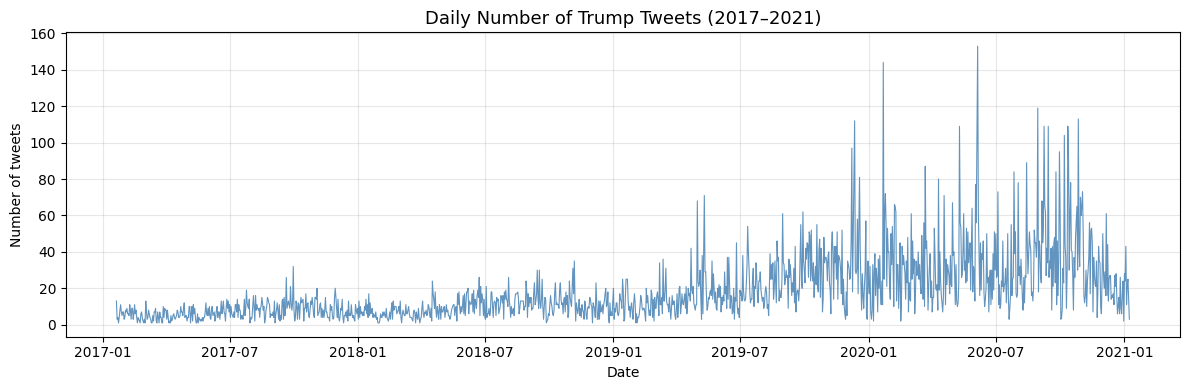

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_tweets.index, daily_tweets["n_tweets"], color="steelblue", linewidth=0.8, alpha=0.85)
ax.set_title("Daily Number of Trump Tweets (2017–2021)", fontsize=13)
ax.set_ylabel("Number of tweets")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/tweets_time_series.png", dpi=150)
plt.show()

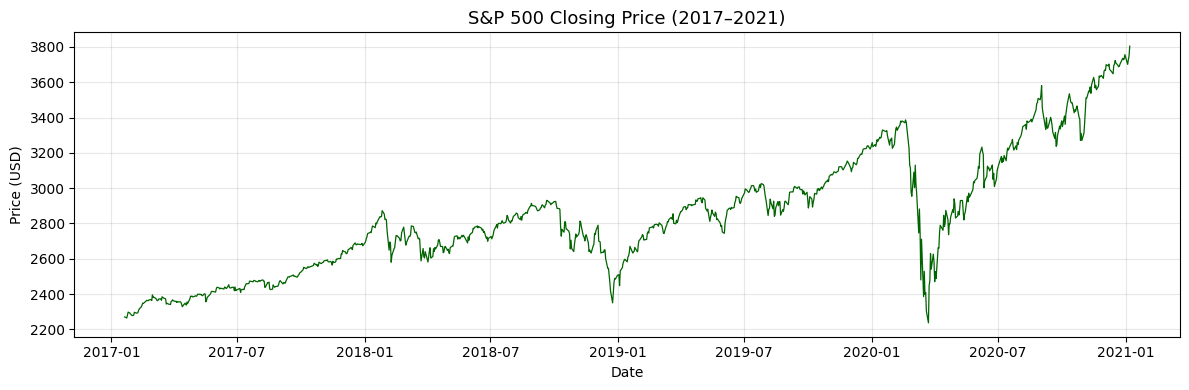

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(stock.index, stock["SP500_Close"], color="darkgreen", linewidth=0.9)
ax.set_title("S&P 500 Closing Price (2017–2021)", fontsize=13)
ax.set_ylabel("Price (USD)")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/sp500_time_series.png", dpi=150)
plt.show()

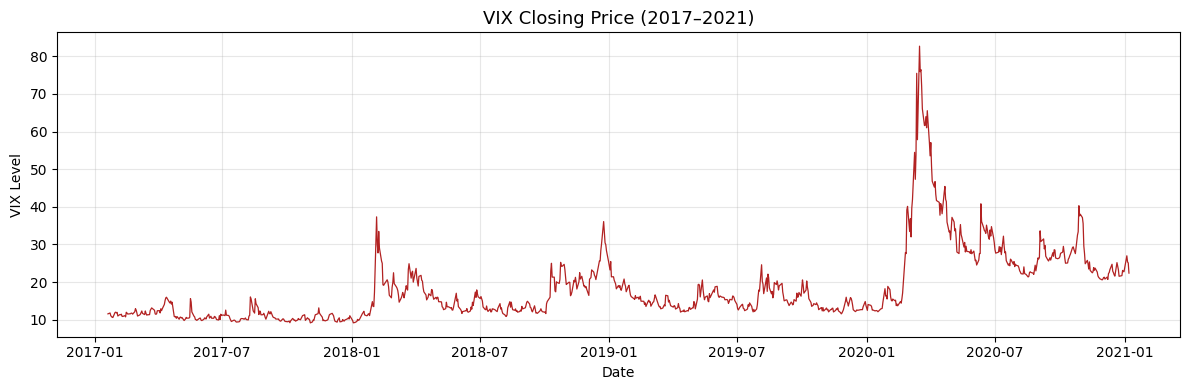

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(stock.index, stock["VIX_Close"], color="firebrick", linewidth=0.9)
ax.set_title("VIX Closing Price (2017–2021)", fontsize=13)
ax.set_ylabel("VIX Level")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/vix_time_series.png", dpi=150)
plt.show()

## 2. Descriptive Statistics Table

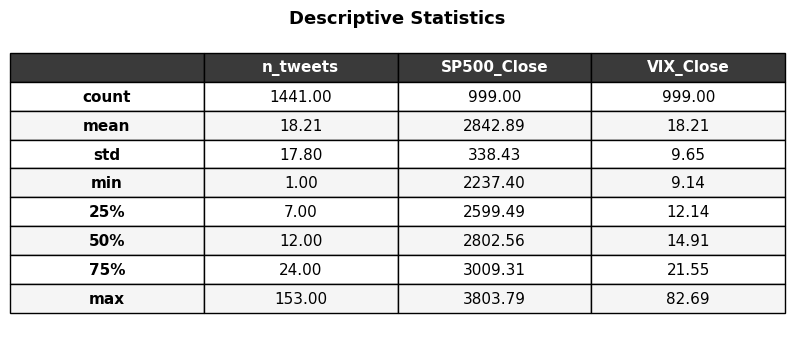

,n_tweets,SP500_Close,VIX_Close
count,1441.000000,999.000000,999.000000
mean,18.208883,2842.887367,18.214635
std,17.801064,338.428473,9.647390
min,1.000000,2237.399902,9.140000
25%,7.000000,2599.489990,12.140000
50%,12.000000,2802.560059,14.910000
75%,24.000000,3009.310059,21.550000
max,153.000000,3803.790039,82.690002


In [6]:
stats_df = pd.DataFrame({
    "n_tweets": daily_tweets["n_tweets"],
    "SP500_Close": stock["SP500_Close"],
    "VIX_Close": stock["VIX_Close"],
})

desc = stats_df.describe().loc[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
desc.columns = ["n_tweets", "SP500_Close", "VIX_Close"]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.axis("off")

table_data = [[idx] + [f"{v:.2f}" if pd.notna(v) else "" for v in row] for idx, row in desc.iterrows()]
col_labels = [""] + list(desc.columns)

tbl = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 1.6)

# Style header row
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor("#3a3a3a")
    tbl[0, j].set_text_props(color="white", fontweight="bold")

# Alternate row shading
for i in range(1, len(table_data) + 1):
    for j in range(len(col_labels)):
        tbl[i, j].set_facecolor("#f5f5f5" if i % 2 == 0 else "white")
        if j == 0:
            tbl[i, j].set_text_props(fontweight="bold")

ax.set_title("Descriptive Statistics", fontsize=13, pad=10, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/descriptive_stats_table.png", dpi=150, bbox_inches="tight")
plt.show()

desc

## 3. Distribution with Kernel Density Estimation

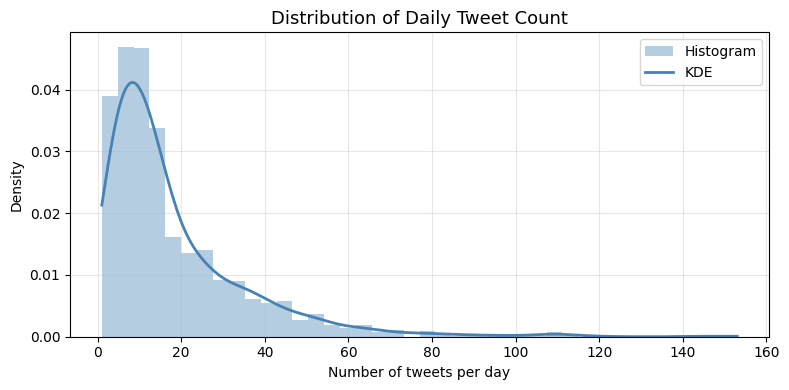

In [7]:
data = daily_tweets["n_tweets"].dropna()
kde = gaussian_kde(data)
x = np.linspace(data.min(), data.max(), 300)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(data, bins=40, density=True, color="steelblue", alpha=0.4, label="Histogram")
ax.plot(x, kde(x), color="steelblue", linewidth=2, label="KDE")
ax.set_title("Distribution of Daily Tweet Count", fontsize=13)
ax.set_xlabel("Number of tweets per day")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/kde_tweets.png", dpi=150)
plt.show()

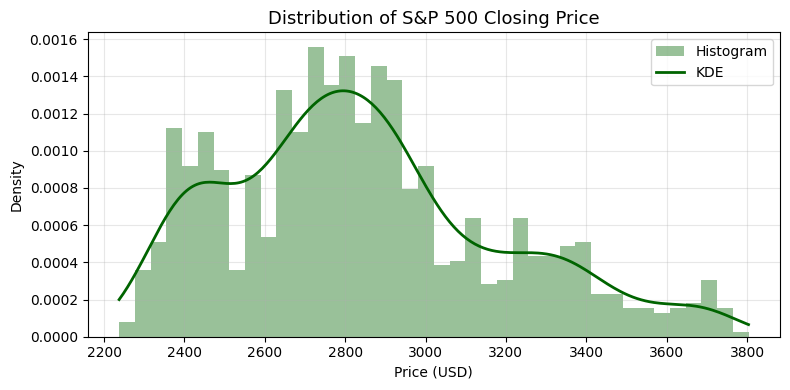

In [8]:
data = stock["SP500_Close"].dropna()
kde = gaussian_kde(data)
x = np.linspace(data.min(), data.max(), 300)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(data, bins=40, density=True, color="darkgreen", alpha=0.4, label="Histogram")
ax.plot(x, kde(x), color="darkgreen", linewidth=2, label="KDE")
ax.set_title("Distribution of S&P 500 Closing Price", fontsize=13)
ax.set_xlabel("Price (USD)")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/kde_sp500.png", dpi=150)
plt.show()

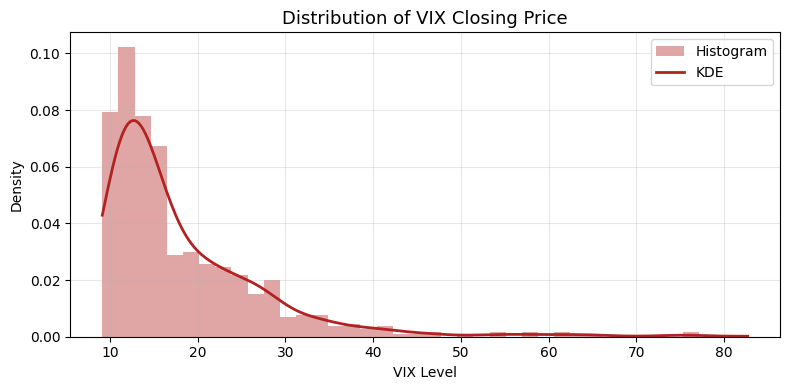

In [9]:
data = stock["VIX_Close"].dropna()
kde = gaussian_kde(data)
x = np.linspace(data.min(), data.max(), 300)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(data, bins=40, density=True, color="firebrick", alpha=0.4, label="Histogram")
ax.plot(x, kde(x), color="firebrick", linewidth=2, label="KDE")
ax.set_title("Distribution of VIX Closing Price", fontsize=13)
ax.set_xlabel("VIX Level")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/kde_vix.png", dpi=150)
plt.show()

## 4. Additional Descriptive Plots

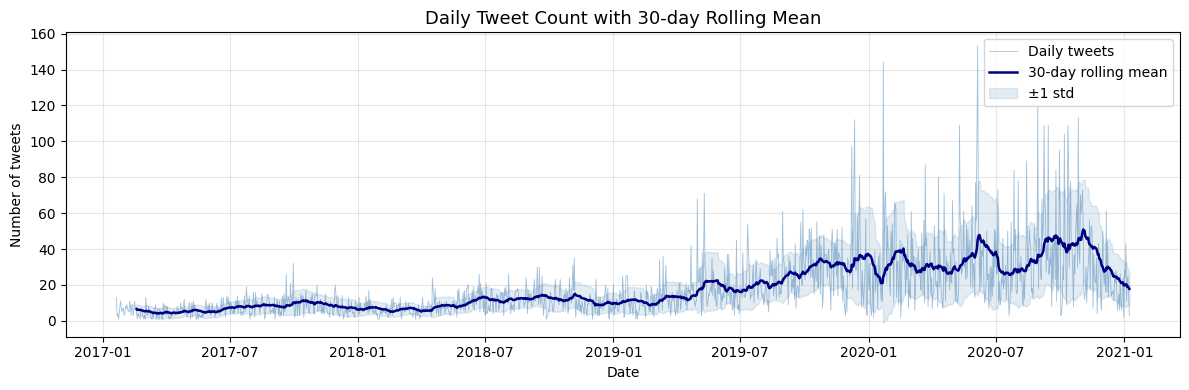

In [10]:
# Rolling 30-day mean & std for tweet count
roll = daily_tweets["n_tweets"].rolling(30)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_tweets.index, daily_tweets["n_tweets"], color="steelblue",
        linewidth=0.6, alpha=0.5, label="Daily tweets")
ax.plot(roll.mean().index, roll.mean(), color="navy", linewidth=1.8,
        label="30-day rolling mean")
ax.fill_between(roll.mean().index,
                roll.mean() - roll.std(),
                roll.mean() + roll.std(),
                color="steelblue", alpha=0.15, label="±1 std")
ax.set_title("Daily Tweet Count with 30-day Rolling Mean", fontsize=13)
ax.set_ylabel("Number of tweets")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/tweets_rolling_mean.png", dpi=150)
plt.show()


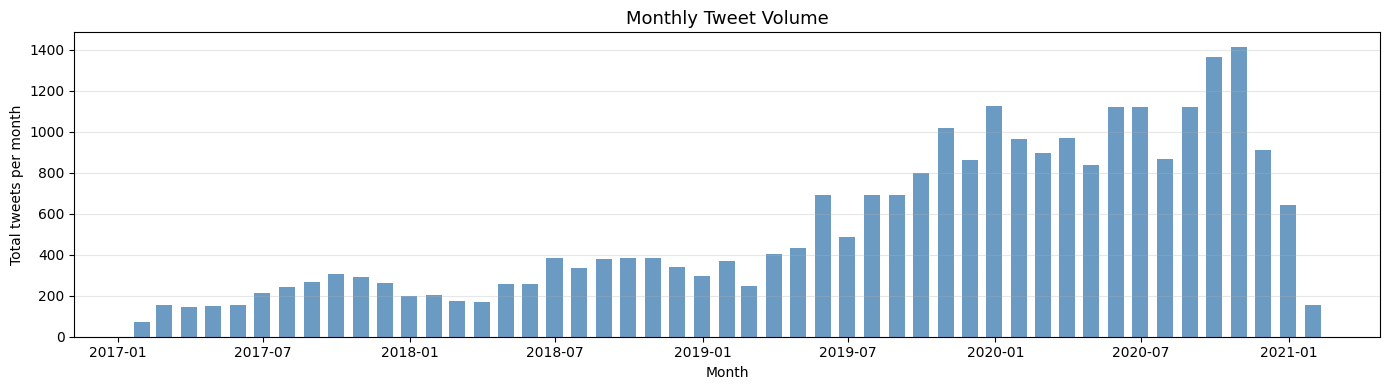

In [11]:
# Monthly tweet volume bar chart
monthly = daily_tweets["n_tweets"].resample("ME").sum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(monthly.index, monthly.values, width=20, color="steelblue", alpha=0.8)
ax.set_title("Monthly Tweet Volume", fontsize=13)
ax.set_ylabel("Total tweets per month")
ax.set_xlabel("Month")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/tweets_monthly_bar.png", dpi=150)
plt.show()


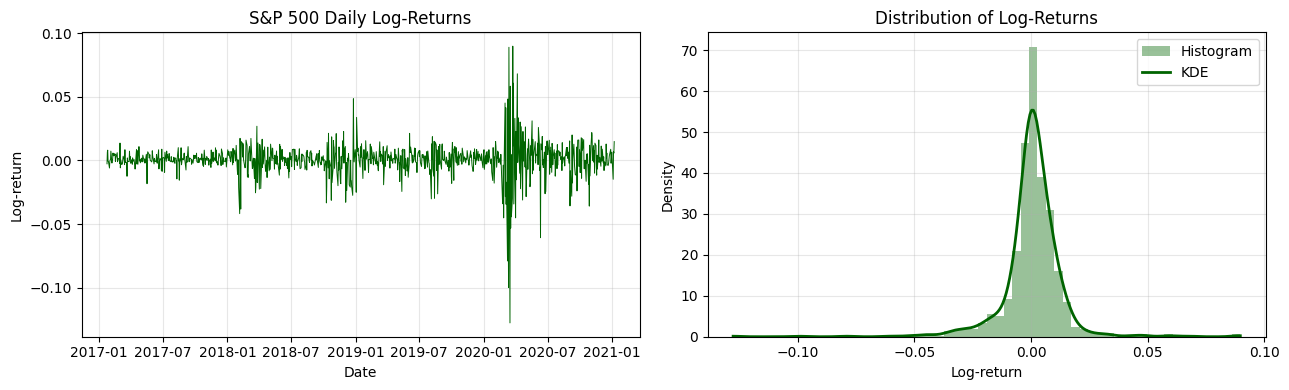

Mean    : 0.00052
Std     : 0.01305
Skewness: -1.142
Kurtosis: 20.691


In [12]:
# SP500 daily log-returns
sp500_ret = np.log(stock["SP500_Close"]).diff().dropna()
sp500_ret.name = "SP500_log_return"

from scipy.stats import gaussian_kde as gkde, kurtosis, skew
kde_r = gkde(sp500_ret)
xr = np.linspace(sp500_ret.min(), sp500_ret.max(), 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(sp500_ret.index, sp500_ret, color="darkgreen", linewidth=0.7)
axes[0].set_title("S&P 500 Daily Log-Returns", fontsize=12)
axes[0].set_ylabel("Log-return")
axes[0].set_xlabel("Date")
axes[0].grid(True, alpha=0.3)

axes[1].hist(sp500_ret, bins=60, density=True, color="darkgreen", alpha=0.4, label="Histogram")
axes[1].plot(xr, kde_r(xr), color="darkgreen", linewidth=2, label="KDE")
axes[1].set_title("Distribution of Log-Returns", fontsize=12)
axes[1].set_xlabel("Log-return")
axes[1].set_ylabel("Density")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/sp500_log_returns.png", dpi=150)
plt.show()

print(f"Mean    : {sp500_ret.mean():.5f}")
print(f"Std     : {sp500_ret.std():.5f}")
print(f"Skewness: {skew(sp500_ret):.3f}")
print(f"Kurtosis: {kurtosis(sp500_ret):.3f}")


## 5. Stationarity Tests (ADF — Augmented Dickey-Fuller)

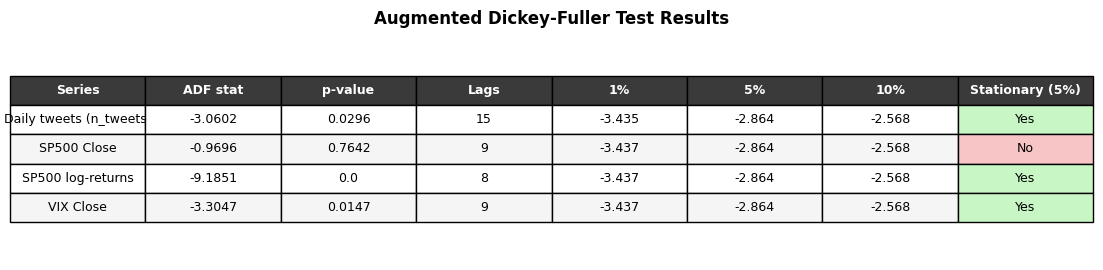

                         ADF stat  p-value  Lags     1%     5%    10% Stationary (5%)
Series                                                                               
Daily tweets (n_tweets)   -3.0602   0.0296    15 -3.435 -2.864 -2.568             Yes
SP500 Close               -0.9696   0.7642     9 -3.437 -2.864 -2.568              No
SP500 log-returns         -9.1851   0.0000     8 -3.437 -2.864 -2.568             Yes
VIX Close                 -3.3047   0.0147     9 -3.437 -2.864 -2.568             Yes


In [13]:
from statsmodels.tsa.stattools import adfuller

sp500_ret = np.log(stock["SP500_Close"]).diff().dropna()

series = {
    "Daily tweets (n_tweets)": daily_tweets["n_tweets"].dropna(),
    "SP500 Close":             stock["SP500_Close"].dropna(),
    "SP500 log-returns":       sp500_ret,
    "VIX Close":               stock["VIX_Close"].dropna(),
}

results = []
for name, s in series.items():
    r = adfuller(s, autolag="AIC")
    results.append({
        "Series": name,
        "ADF stat": round(r[0], 4),
        "p-value": round(r[1], 4),
        "Lags": r[2],
        "1%": round(r[4]["1%"], 3),
        "5%": round(r[4]["5%"], 3),
        "10%": round(r[4]["10%"], 3),
        "Stationary (5%)": "Yes" if r[1] < 0.05 else "No",
    })

adf_df = pd.DataFrame(results).set_index("Series")

# Plot as table
fig, ax = plt.subplots(figsize=(11, 2.8))
ax.axis("off")
col_labels = list(adf_df.columns)
table_data = [[idx] + list(row) for idx, row in zip(adf_df.index, adf_df.values)]

tbl = ax.table(
    cellText=table_data,
    colLabels=["Series"] + col_labels,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.1, 1.7)

for j in range(len(col_labels) + 1):
    tbl[0, j].set_facecolor("#3a3a3a")
    tbl[0, j].set_text_props(color="white", fontweight="bold")
for i in range(1, len(results) + 1):
    for j in range(len(col_labels) + 1):
        tbl[i, j].set_facecolor("#f5f5f5" if i % 2 == 0 else "white")
    # Color "Stationary" column
    val = table_data[i - 1][-1]
    tbl[i, len(col_labels)].set_facecolor("#c8f7c5" if val == "Yes" else "#f7c5c5")

ax.set_title("Augmented Dickey-Fuller Test Results", fontsize=12, fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/adf_table.png", dpi=150, bbox_inches="tight")
plt.show()

print(adf_df.to_string())


## 6. Correlograms (ACF / PACF)

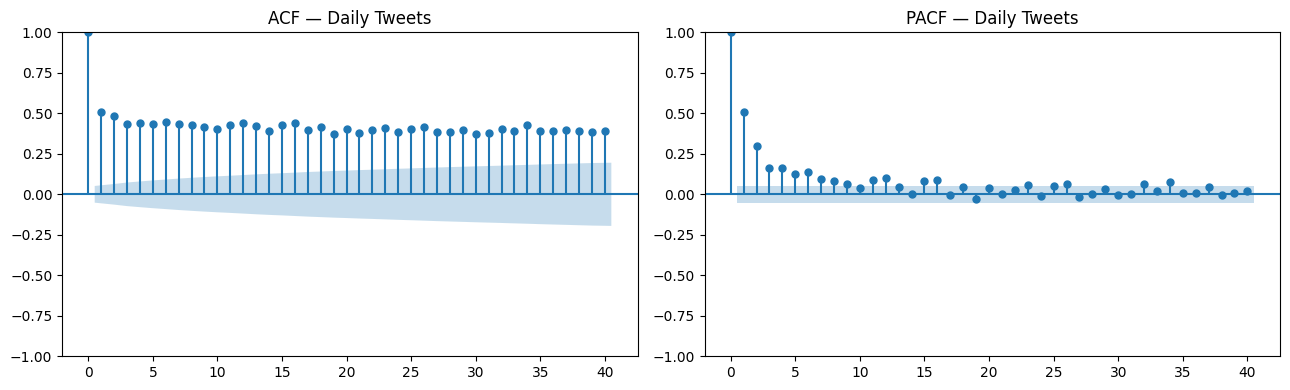

In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(daily_tweets["n_tweets"].dropna(), lags=40, ax=axes[0], title="ACF — Daily Tweets")
plot_pacf(daily_tweets["n_tweets"].dropna(), lags=40, ax=axes[1], title="PACF — Daily Tweets", method="ywm")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/correlogram_tweets.png", dpi=150)
plt.show()


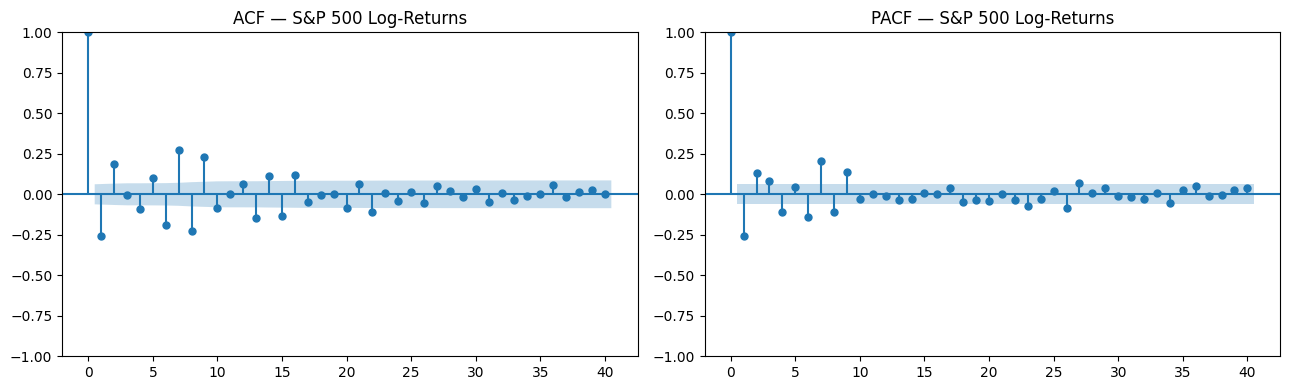

In [15]:
sp500_ret = np.log(stock["SP500_Close"]).diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(sp500_ret, lags=40, ax=axes[0], title="ACF — S&P 500 Log-Returns")
plot_pacf(sp500_ret, lags=40, ax=axes[1], title="PACF — S&P 500 Log-Returns", method="ywm")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/correlogram_sp500_returns.png", dpi=150)
plt.show()


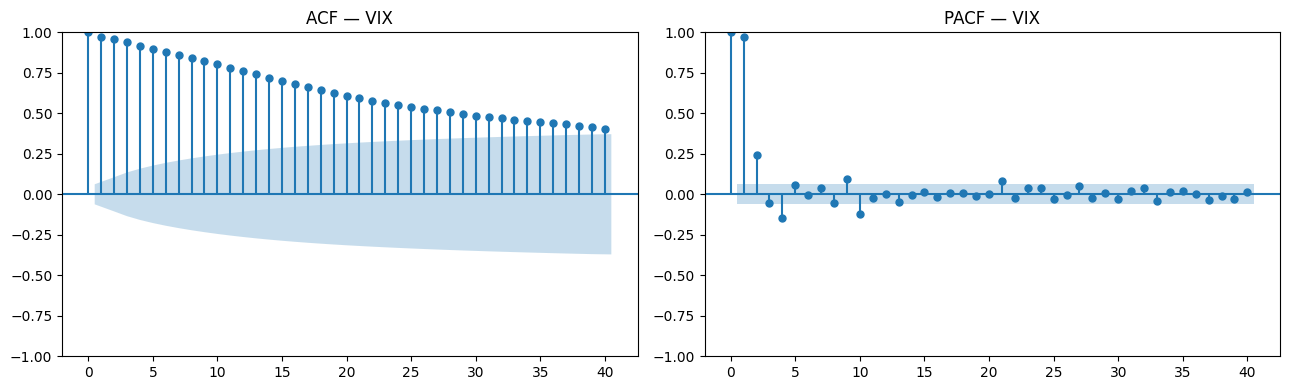

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(stock["VIX_Close"].dropna(), lags=40, ax=axes[0], title="ACF — VIX")
plot_pacf(stock["VIX_Close"].dropna(), lags=40, ax=axes[1], title="PACF — VIX", method="ywm")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/correlogram_vix.png", dpi=150)
plt.show()


---
## 7. ARMA Models

In [17]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import itertools, warnings
warnings.filterwarnings("ignore")

ARMA_DIR = f"{SAVE_DIR}/../arma"
import os; os.makedirs(ARMA_DIR, exist_ok=True)

# Series to model
sp500_ret = np.log(stock["SP500_Close"]).diff().dropna()
series_dict = {
    "tweets":  ("Daily Tweets",           daily_tweets["n_tweets"].dropna()),
    "sp500":   ("S&P 500 Log-Returns",    sp500_ret),
    "vix":     ("VIX Close",              stock["VIX_Close"].dropna()),
}


In [18]:
def grid_search_arma(series, name, max_p=3, max_q=3):
    results = []
    for p, q in itertools.product(range(max_p + 1), range(max_q + 1)):
        if p == 0 and q == 0:
            continue
        try:
            m = ARIMA(series, order=(p, 0, q)).fit()
            results.append({"p": p, "q": q, "AIC": round(m.aic, 2), "BIC": round(m.bic, 2)})
        except Exception:
            pass
    df = pd.DataFrame(results).sort_values("AIC")
    print(f"\n=== {name} — Top 5 by AIC ===")
    print(df.head(5).to_string(index=False))
    return df

grids = {}
for key, (name, s) in series_dict.items():
    grids[key] = grid_search_arma(s, name)



=== Daily Tweets — Top 5 by AIC ===
 p  q      AIC      BIC
 3  3 11613.96 11656.15
 1  3 11615.49 11647.13
 3  1 11615.53 11647.17
 3  2 11616.14 11653.05
 2  3 11617.43 11654.35

=== S&P 500 Log-Returns — Top 5 by AIC ===
 p  q      AIC      BIC
 3  2 -5977.57 -5943.23
 0  2 -5914.17 -5894.55
 0  3 -5913.23 -5888.70
 1  3 -5910.96 -5881.53
 3  0 -5910.54 -5886.01

=== VIX Close — Top 5 by AIC ===
 p  q     AIC     BIC
 2  3 4347.34 4381.69
 3  3 4348.63 4387.89
 3  2 4359.96 4394.31
 1  3 4363.67 4393.11
 1  2 4364.69 4389.22


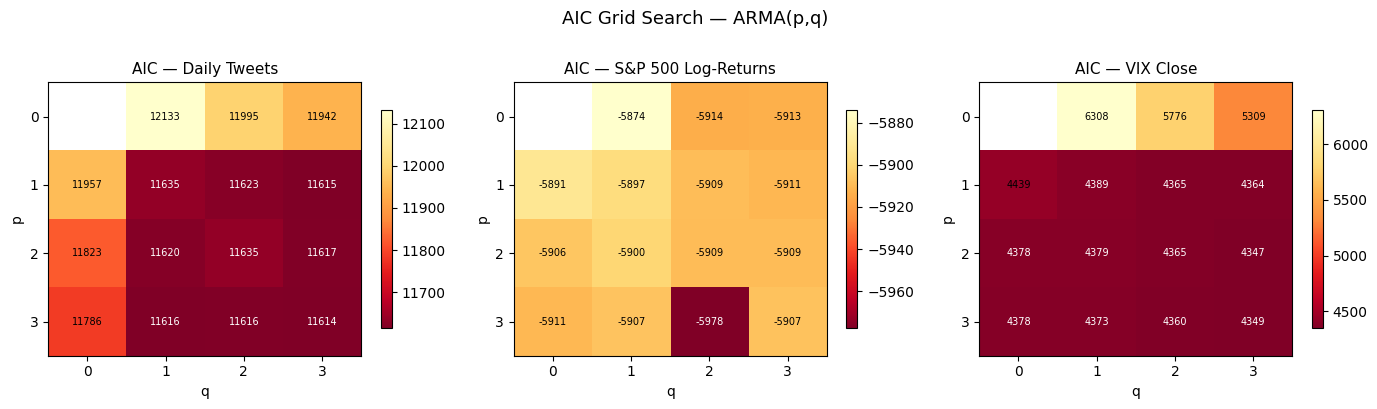

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (key, (name, _)) in zip(axes, series_dict.items()):
    df = grids[key]
    pivot = df.pivot(index="p", columns="q", values="AIC")
    im = ax.imshow(pivot, cmap="YlOrRd_r", aspect="auto")
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
    ax.set_xlabel("q"); ax.set_ylabel("p")
    ax.set_title(f"AIC — {name}", fontsize=11)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.iloc[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=7,
                        color="black" if val > pivot.min().min() + 50 else "white")
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("AIC Grid Search — ARMA(p,q)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{ARMA_DIR}/arma_aic_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


In [20]:
best_models = {}
best_orders = {}
for key, (name, s) in series_dict.items():
    best_row = grids[key].iloc[0]
    p, q = int(best_row["p"]), int(best_row["q"])
    best_orders[key] = (p, q)
    m = ARIMA(s, order=(p, 0, q)).fit()
    best_models[key] = m
    print(f"\n{'='*55}")
    print(f"{name}  →  ARMA({p},{q})")
    print(f"{'='*55}")
    print(m.summary().tables[1])



Daily Tweets  →  ARMA(3,3)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         17.3690     13.517      1.285      0.199      -9.124      43.862
ar.L1          0.5125      0.111      4.632      0.000       0.296       0.729
ar.L2          0.9964      0.010    101.304      0.000       0.977       1.016
ar.L3         -0.5115      0.110     -4.630      0.000      -0.728      -0.295
ma.L1         -0.3316      0.118     -2.817      0.005      -0.562      -0.101
ma.L2         -0.9618      0.015    -63.029      0.000      -0.992      -0.932
ma.L3          0.3515      0.109      3.211      0.001       0.137       0.566
sigma2       182.9856      3.146     58.165      0.000     176.820     189.152

S&P 500 Log-Returns  →  ARMA(3,2)
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

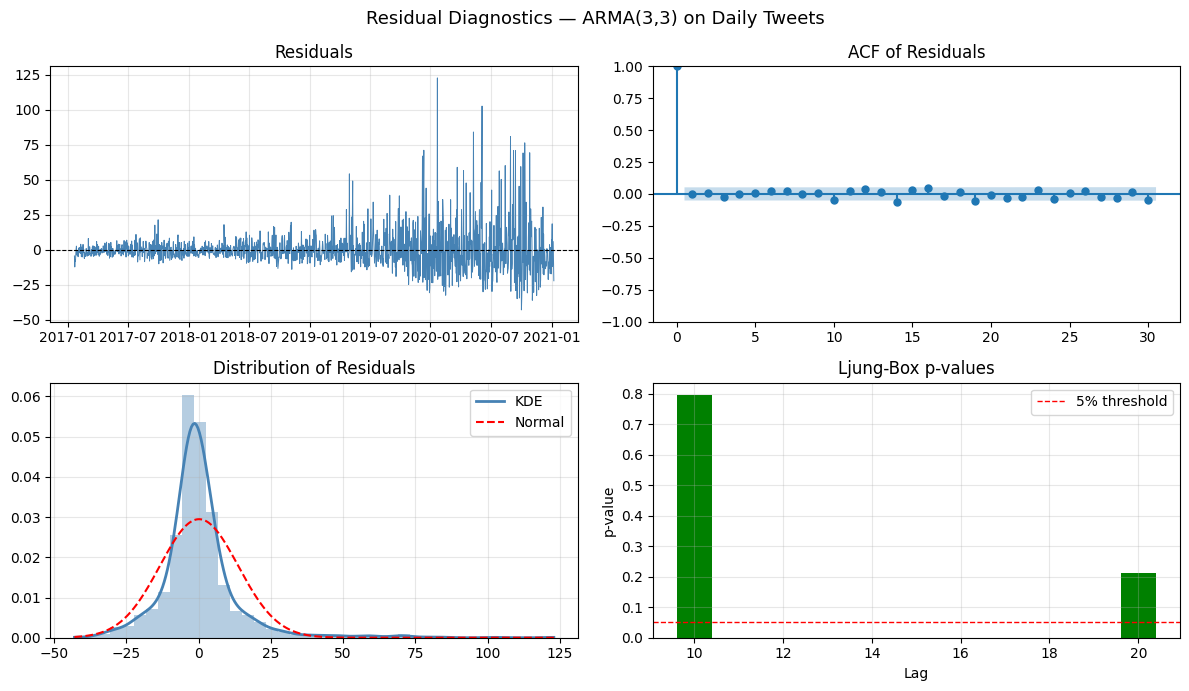

Ljung-Box test (lag 10): p = 0.7975  (OK — white noise)


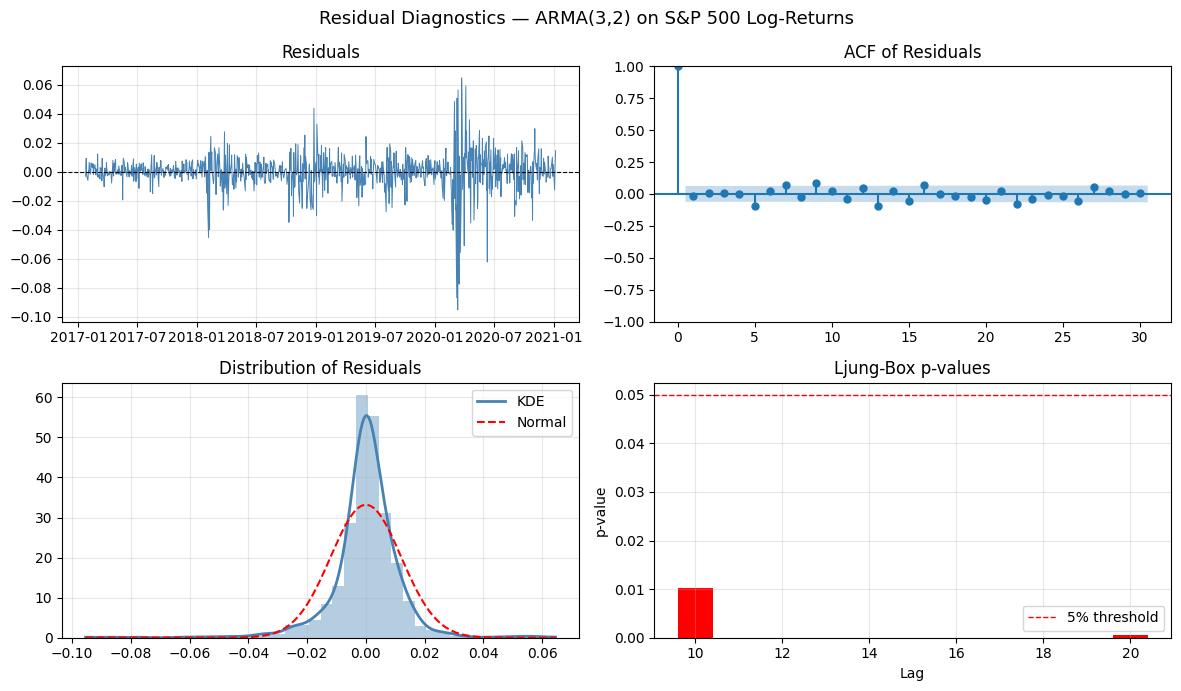

Ljung-Box test (lag 10): p = 0.0103  (FAIL — autocorrelation remains)


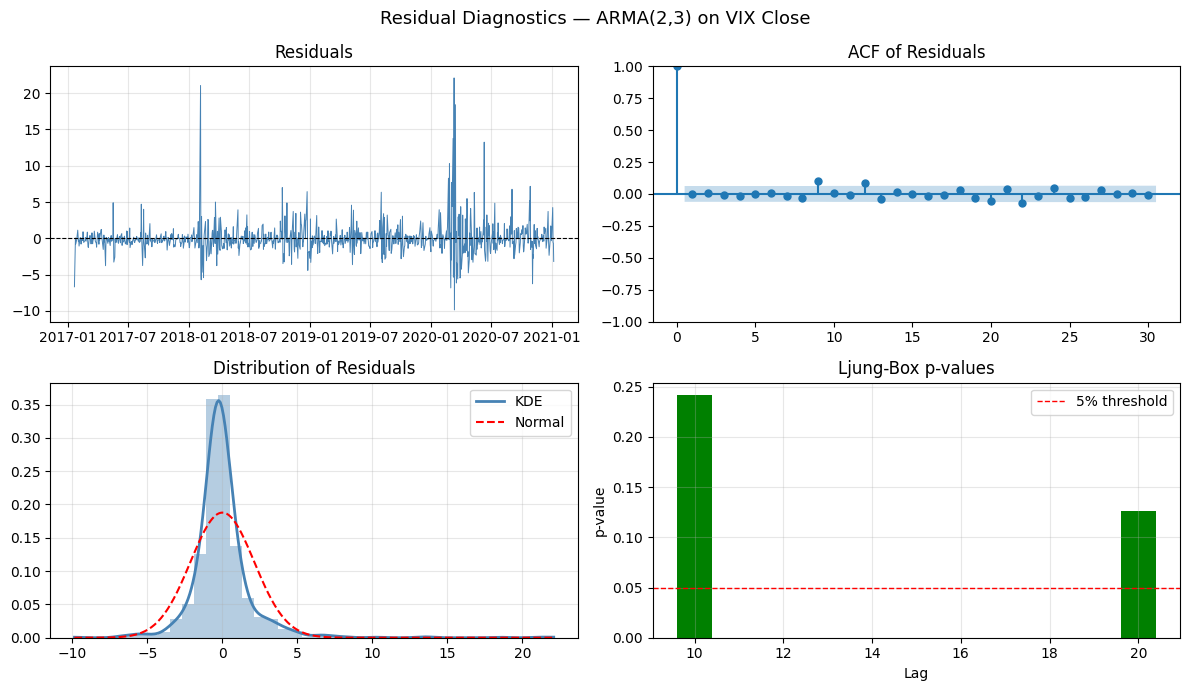

Ljung-Box test (lag 10): p = 0.2421  (OK — white noise)


In [21]:
def plot_residuals(model, name, key, orders):
    resid = model.resid
    lb = acorr_ljungbox(resid, lags=[10, 20], return_df=True)
    p0, q0 = orders

    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    fig.suptitle(f"Residual Diagnostics — ARMA({p0},{q0}) on {name}", fontsize=13)

    # 1. Residuals over time
    axes[0,0].plot(resid.index, resid, linewidth=0.7, color="steelblue")
    axes[0,0].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[0,0].set_title("Residuals")
    axes[0,0].grid(True, alpha=0.3)

    # 2. ACF of residuals
    plot_acf(resid, lags=30, ax=axes[0,1], title="ACF of Residuals")

    # 3. KDE of residuals
    from scipy.stats import norm as spnorm
    from scipy.stats import gaussian_kde as gkde
    kde_r = gkde(resid)
    xr = np.linspace(resid.min(), resid.max(), 300)
    axes[1,0].hist(resid, bins=40, density=True, color="steelblue", alpha=0.4)
    axes[1,0].plot(xr, kde_r(xr), color="steelblue", linewidth=2, label="KDE")
    axes[1,0].plot(xr, spnorm.pdf(xr, resid.mean(), resid.std()),
                   color="red", linewidth=1.5, linestyle="--", label="Normal")
    axes[1,0].set_title("Distribution of Residuals")
    axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

    # 4. Ljung-Box p-values
    axes[1,1].bar(lb.index, lb["lb_pvalue"], color=["green" if p > 0.05 else "red"
                                                      for p in lb["lb_pvalue"]])
    axes[1,1].axhline(0.05, color="red", linestyle="--", linewidth=1, label="5% threshold")
    axes[1,1].set_title("Ljung-Box p-values"); axes[1,1].set_xlabel("Lag")
    axes[1,1].set_ylabel("p-value"); axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{ARMA_DIR}/arma_residuals_{key}.png", dpi=150)
    plt.show()

    print(f"Ljung-Box test (lag 10): p = {lb.loc[10,'lb_pvalue']:.4f}  "
          f"({'OK — white noise' if lb.loc[10,'lb_pvalue'] > 0.05 else 'FAIL — autocorrelation remains'})")

for key, (name, _) in series_dict.items():
    plot_residuals(best_models[key], name, key, best_orders[key])


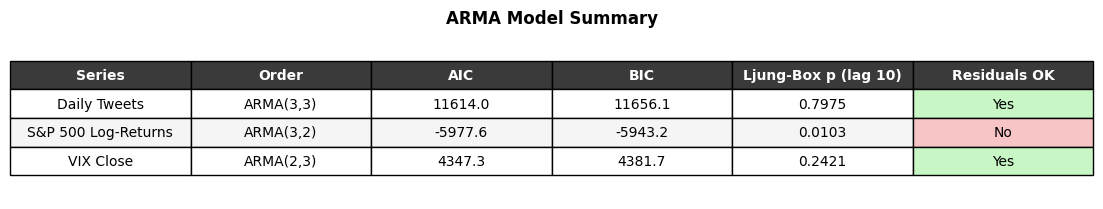

             Series     Order     AIC     BIC Ljung-Box p (lag 10) Residuals OK
       Daily Tweets ARMA(3,3) 11614.0 11656.1               0.7975          Yes
S&P 500 Log-Returns ARMA(3,2) -5977.6 -5943.2               0.0103           No
          VIX Close ARMA(2,3)  4347.3  4381.7               0.2421          Yes


In [22]:
rows = []
for key, (name, _) in series_dict.items():
    m = best_models[key]
    p, q = best_orders[key]
    resid = m.resid
    lb10 = acorr_ljungbox(resid, lags=[10], return_df=True).loc[10, "lb_pvalue"]
    rows.append({
        "Series": name,
        "Order": f"ARMA({p},{q})",
        "AIC": f"{m.aic:.1f}",
        "BIC": f"{m.bic:.1f}",
        "Ljung-Box p (lag 10)": f"{lb10:.4f}",
        "Residuals OK": "Yes" if lb10 > 0.05 else "No",
    })

summary_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(11, 2.2))
ax.axis("off")
tbl = ax.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    cellLoc="center", loc="center"
)
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.1, 1.8)
for j in range(len(summary_df.columns)):
    tbl[0, j].set_facecolor("#3a3a3a")
    tbl[0, j].set_text_props(color="white", fontweight="bold")
for i in range(1, len(rows) + 1):
    for j in range(len(summary_df.columns)):
        tbl[i, j].set_facecolor("#f5f5f5" if i % 2 == 0 else "white")
    ok = summary_df.iloc[i-1]["Residuals OK"]
    tbl[i, len(summary_df.columns)-1].set_facecolor("#c8f7c5" if ok == "Yes" else "#f7c5c5")

ax.set_title("ARMA Model Summary", fontsize=12, fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig(f"{ARMA_DIR}/arma_summary_table.png", dpi=150, bbox_inches="tight")
plt.show()
print(summary_df.to_string(index=False))


---
## 8. GARCH Models

In [23]:
from arch import arch_model
from arch.unitroot import ADF as ArchADF
from statsmodels.stats.diagnostic import het_arch
import warnings
warnings.filterwarnings("ignore")

GARCH_DIR = f"{SAVE_DIR}/../garch"
import os; os.makedirs(GARCH_DIR, exist_ok=True)

sp500_ret = np.log(stock["SP500_Close"]).diff().dropna()


In [24]:
# ARCH-LM test on ARMA residuals (already fitted in best_models)
print("ARCH-LM test on ARMA residuals (H0: no ARCH effects)")
print("-"*55)
arch_results = []
for key, (name, _) in series_dict.items():
    resid = best_models[key].resid.dropna()
    lm_stat, lm_pval, f_stat, f_pval = het_arch(resid, nlags=10)
    sig = "Yes ***" if lm_pval < 0.01 else ("Yes *" if lm_pval < 0.05 else "No")
    arch_results.append({"Series": name, "LM stat": round(lm_stat, 3),
                         "p-value": round(lm_pval, 4), "ARCH effects": sig})
    print(f"{name:28s}  LM={lm_stat:8.3f}  p={lm_pval:.4f}  →  {sig}")

arch_df = pd.DataFrame(arch_results)


ARCH-LM test on ARMA residuals (H0: no ARCH effects)
-------------------------------------------------------
Daily Tweets                  LM=  68.246  p=0.0000  →  Yes ***
S&P 500 Log-Returns           LM= 336.410  p=0.0000  →  Yes ***
VIX Close                     LM= 161.868  p=0.0000  →  Yes ***


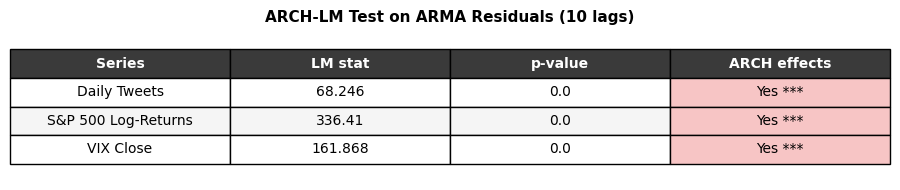

In [25]:
fig, ax = plt.subplots(figsize=(9, 2.0))
ax.axis("off")
tbl = ax.table(cellText=arch_df.values, colLabels=arch_df.columns,
               cellLoc="center", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.1, 1.8)
for j in range(len(arch_df.columns)):
    tbl[0, j].set_facecolor("#3a3a3a")
    tbl[0, j].set_text_props(color="white", fontweight="bold")
for i in range(1, len(arch_df) + 1):
    for j in range(len(arch_df.columns)):
        tbl[i, j].set_facecolor("#f5f5f5" if i % 2 == 0 else "white")
    sig = arch_df.iloc[i-1]["ARCH effects"]
    tbl[i, len(arch_df.columns)-1].set_facecolor("#f7c5c5" if sig.startswith("Yes") else "#c8f7c5")
ax.set_title("ARCH-LM Test on ARMA Residuals (10 lags)", fontsize=11, fontweight="bold", pad=8)
plt.tight_layout()
plt.savefig(f"{GARCH_DIR}/arch_lm_table.png", dpi=150, bbox_inches="tight")
plt.show()


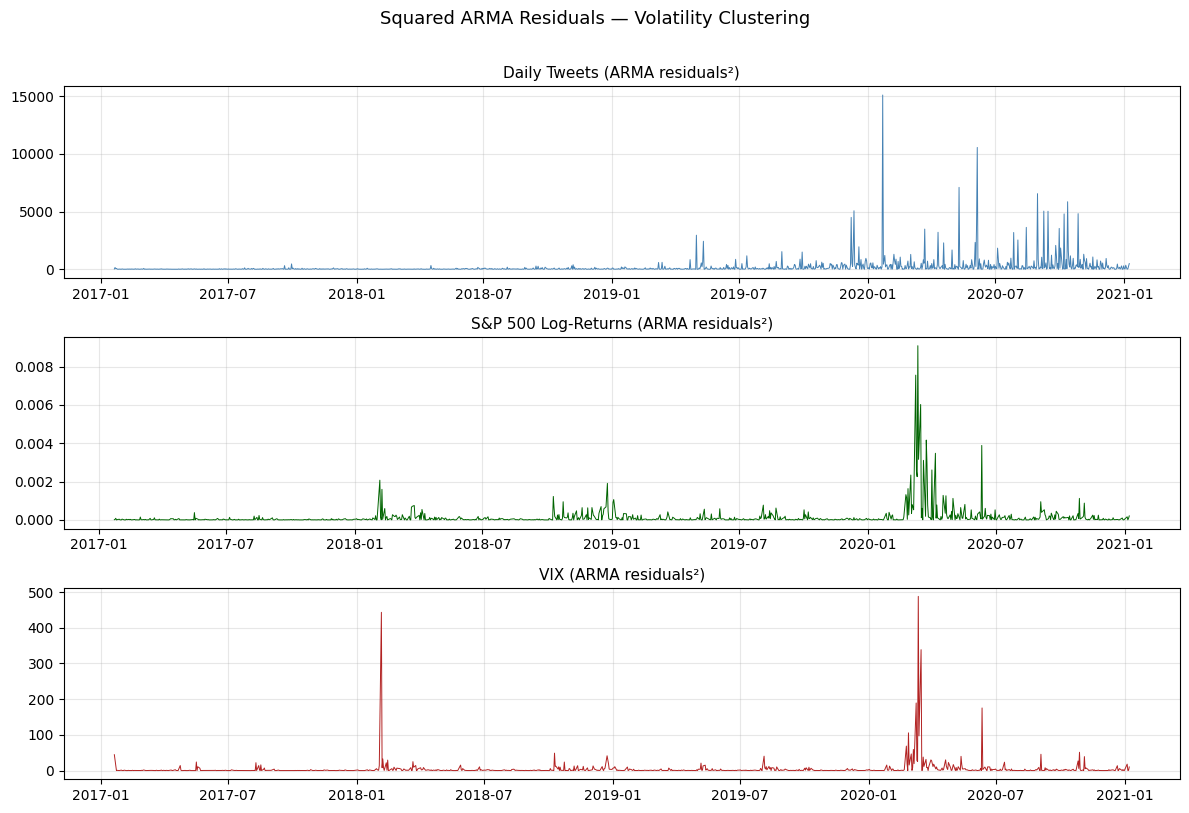

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
labels = {"tweets": "Daily Tweets (ARMA residuals²)",
          "sp500":  "S&P 500 Log-Returns (ARMA residuals²)",
          "vix":    "VIX (ARMA residuals²)"}
colors  = {"tweets": "steelblue", "sp500": "darkgreen", "vix": "firebrick"}

for ax, key in zip(axes, ["tweets", "sp500", "vix"]):
    resid2 = best_models[key].resid ** 2
    ax.plot(resid2.index, resid2, linewidth=0.7, color=colors[key])
    ax.set_title(labels[key], fontsize=11)
    ax.grid(True, alpha=0.3)

plt.suptitle("Squared ARMA Residuals — Volatility Clustering", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{GARCH_DIR}/squared_residuals.png", dpi=150, bbox_inches="tight")
plt.show()


In [27]:
# Grid search GARCH(p,q) on SP500 log-returns (scaled x100 for numerical stability)
ret_scaled = sp500_ret * 100

garch_results = []
for p in range(1, 4):
    for q in range(1, 4):
        try:
            m = arch_model(ret_scaled, vol="Garch", p=p, q=q, dist="normal").fit(disp="off")
            garch_results.append({"p": p, "q": q, "AIC": round(m.aic, 2), "BIC": round(m.bic, 2)})
        except Exception:
            pass

garch_grid = pd.DataFrame(garch_results).sort_values("AIC")
print("=== GARCH grid search — S&P 500 log-returns ===")
print(garch_grid.head(6).to_string(index=False))


=== GARCH grid search — S&P 500 log-returns ===
 p  q     AIC     BIC
 1  1 2449.13 2468.76
 3  1 2449.35 2478.78
 2  2 2449.66 2479.09
 2  1 2449.74 2474.27
 1  2 2451.13 2475.66
 3  2 2451.35 2485.69


In [28]:
# Best model for SP500: GARCH(p,q) from grid
best_garch_row = garch_grid.iloc[0]
gp, gq = int(best_garch_row["p"]), int(best_garch_row["q"])

garch_sp500 = arch_model(ret_scaled, vol="Garch", p=gp, q=gq, dist="normal").fit(disp="off")
print(f"\n=== S&P 500 — GARCH({gp},{gq}) ===")
print(garch_sp500.summary())

# GARCH(1,1) on VIX residuals (scaled)
vix_resid = best_models["vix"].resid
vix_scaled = (vix_resid - vix_resid.mean()) / vix_resid.std() * 10
garch_vix = arch_model(vix_scaled, vol="Garch", p=1, q=1, dist="normal").fit(disp="off")
print(f"\n=== VIX Residuals — GARCH(1,1) ===")
print(garch_vix.summary())



=== S&P 500 — GARCH(1,1) ===
                     Constant Mean - GARCH Model Results                      
Dep. Variable:            SP500_Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1220.57
Distribution:                  Normal   AIC:                           2449.13
Method:            Maximum Likelihood   BIC:                           2468.76
                                        No. Observations:                  998
Date:                Tue, Apr 07 2026   Df Residuals:                      997
Time:                        14:33:11   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1103  2.089e-02  

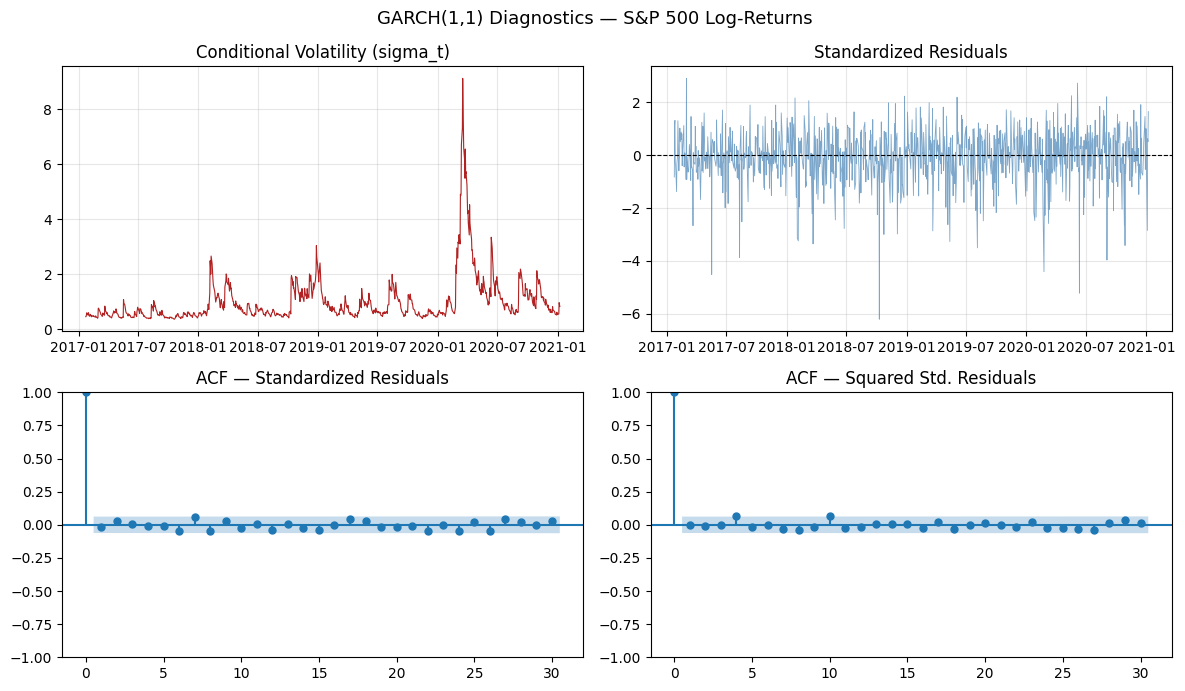

Ljung-Box on squared std residuals (lag 10): p = 0.2622  (OK — no ARCH effects remain)


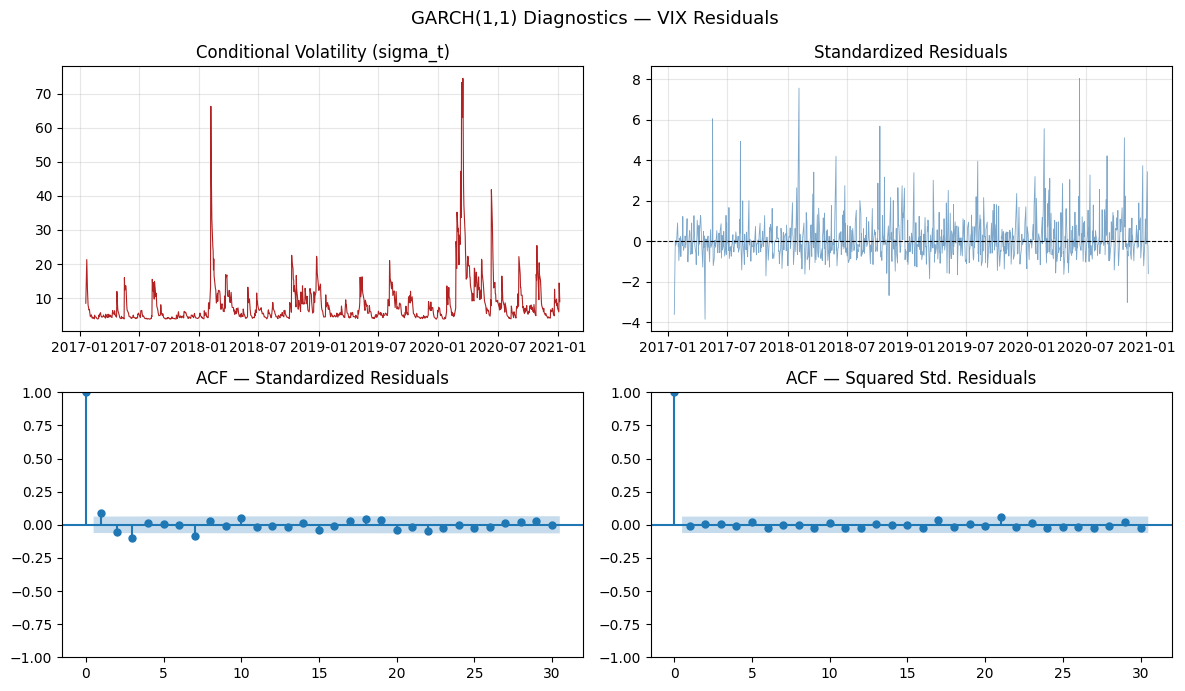

Ljung-Box on squared std residuals (lag 10): p = 0.9936  (OK — no ARCH effects remain)


In [29]:
def plot_garch_diagnostics(fit, name, key, p, q):
    std_resid = fit.std_resid
    cond_vol  = fit.conditional_volatility

    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    fig.suptitle(f"GARCH({p},{q}) Diagnostics — {name}", fontsize=13)

    axes[0,0].plot(cond_vol.index, cond_vol, color="firebrick", linewidth=0.8)
    axes[0,0].set_title("Conditional Volatility (sigma_t)")
    axes[0,0].grid(True, alpha=0.3)

    axes[0,1].plot(std_resid.index, std_resid, color="steelblue", linewidth=0.6, alpha=0.7)
    axes[0,1].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[0,1].set_title("Standardized Residuals")
    axes[0,1].grid(True, alpha=0.3)

    plot_acf(std_resid.dropna(), lags=30, ax=axes[1,0], title="ACF — Standardized Residuals")
    plot_acf(std_resid.dropna()**2, lags=30, ax=axes[1,1], title="ACF — Squared Std. Residuals")

    plt.tight_layout()
    plt.savefig(f"{GARCH_DIR}/garch_diagnostics_{key}.png", dpi=150)
    plt.show()

    lb = acorr_ljungbox(std_resid.dropna()**2, lags=[10], return_df=True)
    p10 = lb.loc[10, "lb_pvalue"]
    print(f"Ljung-Box on squared std residuals (lag 10): p = {p10:.4f}  "
          f"({'OK — no ARCH effects remain' if p10 > 0.05 else 'ARCH effects remain'})")

plot_garch_diagnostics(garch_sp500, "S&P 500 Log-Returns", "sp500", gp, gq)
plot_garch_diagnostics(garch_vix,   "VIX Residuals",        "vix",   1,  1)


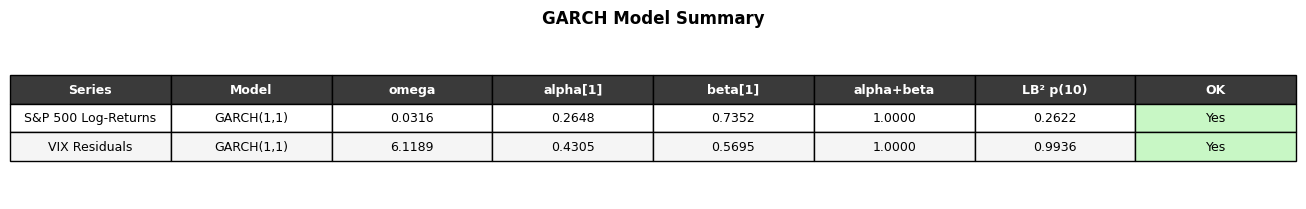

             Series      Model  omega alpha[1] beta[1] alpha+beta LB² p(10)  OK
S&P 500 Log-Returns GARCH(1,1) 0.0316   0.2648  0.7352     1.0000    0.2622 Yes
      VIX Residuals GARCH(1,1) 6.1189   0.4305  0.5695     1.0000    0.9936 Yes


In [30]:
rows_g = []
for fit, name, p, q in [(garch_sp500, "S&P 500 Log-Returns", gp, gq),
                         (garch_vix,   "VIX Residuals",        1,   1)]:
    std_resid = fit.std_resid.dropna()
    lb = acorr_ljungbox(std_resid**2, lags=[10], return_df=True)
    p10 = lb.loc[10, "lb_pvalue"]
    params = fit.params
    rows_g.append({
        "Series":    name,
        "Model":     f"GARCH({p},{q})",
        "omega":     f"{params['omega']:.4f}",
        "alpha[1]":  f"{params.get('alpha[1]', float('nan')):.4f}",
        "beta[1]":   f"{params.get('beta[1]', float('nan')):.4f}",
        "alpha+beta": f"{params.get('alpha[1]', 0) + params.get('beta[1]', 0):.4f}",
        "LB² p(10)": f"{p10:.4f}",
        "OK":        "Yes" if p10 > 0.05 else "No",
    })

gsumm = pd.DataFrame(rows_g)
fig, ax = plt.subplots(figsize=(13, 2.2))
ax.axis("off")
tbl = ax.table(cellText=gsumm.values, colLabels=gsumm.columns,
               cellLoc="center", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.1, 1.8)
for j in range(len(gsumm.columns)):
    tbl[0, j].set_facecolor("#3a3a3a")
    tbl[0, j].set_text_props(color="white", fontweight="bold")
for i in range(1, len(rows_g) + 1):
    for j in range(len(gsumm.columns)):
        tbl[i, j].set_facecolor("#f5f5f5" if i % 2 == 0 else "white")
    tbl[i, len(gsumm.columns)-1].set_facecolor("#c8f7c5" if gsumm.iloc[i-1]["OK"] == "Yes" else "#f7c5c5")
ax.set_title("GARCH Model Summary", fontsize=12, fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig(f"{GARCH_DIR}/garch_summary_table.png", dpi=150, bbox_inches="tight")
plt.show()
print(gsumm.to_string(index=False))


---
## 9. Stationarity Tests (ADF, KPSS, PP)

In [31]:
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron

sp500_ret = np.log(stock["SP500_Close"]).diff().dropna()

STAT_DIR = f"{SAVE_DIR}/../stationarity"
os.makedirs(STAT_DIR, exist_ok=True)

series_stat = {
    "Daily Tweets":          daily_tweets["n_tweets"].dropna(),
    "SP500 Close":           stock["SP500_Close"].dropna(),
    "SP500 Log-Returns":     sp500_ret,
    "VIX Close":             stock["VIX_Close"].dropna(),
}

rows_stat = []
for name, s in series_stat.items():
    # ADF (with constant)
    adf_r  = adfuller(s, autolag="AIC", regression="c")
    adf_stat, adf_p = adf_r[0], adf_r[1]

    # ADF (with trend)
    adf_rt = adfuller(s, autolag="AIC", regression="ct")
    adf_stat_t, adf_p_t = adf_rt[0], adf_rt[1]

    # KPSS (H0: stationary)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")

    # Phillips-Perron
    pp = PhillipsPerron(s)
    pp_stat, pp_p = pp.stat, pp.pvalue

    # Conclusion
    adf_ok  = adf_p  < 0.05
    kpss_ok = kpss_p > 0.05   # KPSS: reject H0 means NON-stationary
    pp_ok   = pp_p   < 0.05
    stationary = "Yes" if (adf_ok and kpss_ok and pp_ok) else (
                 "Partial" if (adf_ok or pp_ok) else "No")

    rows_stat.append({
        "Series":           name,
        "ADF stat (c)":     f"{adf_stat:.3f}",
        "ADF p (c)":        f"{adf_p:.4f}",
        "ADF p (ct)":       f"{adf_p_t:.4f}",
        "KPSS stat":        f"{kpss_stat:.3f}",
        "KPSS p":           f"{kpss_p:.4f}",
        "PP stat":          f"{pp_stat:.3f}",
        "PP p":             f"{pp_p:.4f}",
        "Stationary":       stationary,
    })
    print(f"{name:22s}  ADF={adf_p:.4f}  KPSS={kpss_p:.4f}  PP={pp_p:.4f}  → {stationary}")

stat_df = pd.DataFrame(rows_stat)


Daily Tweets            ADF=0.0296  KPSS=0.0100  PP=0.0000  → Partial
SP500 Close             ADF=0.7642  KPSS=0.0100  PP=0.8187  → No
SP500 Log-Returns       ADF=0.0000  KPSS=0.1000  PP=0.0000  → Yes
VIX Close               ADF=0.0147  KPSS=0.0100  PP=0.0055  → Partial


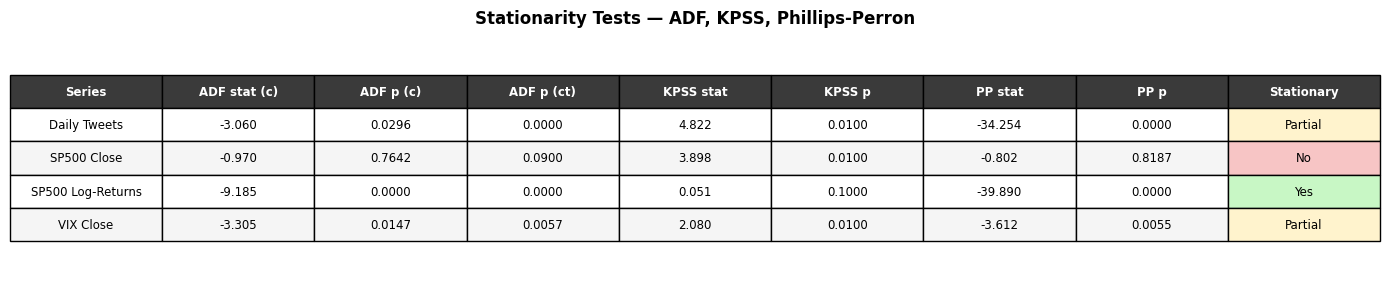

In [32]:
fig, ax = plt.subplots(figsize=(14, 3.0))
ax.axis("off")
tbl = ax.table(cellText=stat_df.values, colLabels=stat_df.columns,
               cellLoc="center", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1.0, 1.9)
for j in range(len(stat_df.columns)):
    tbl[0, j].set_facecolor("#3a3a3a")
    tbl[0, j].set_text_props(color="white", fontweight="bold")
for i in range(1, len(rows_stat) + 1):
    for j in range(len(stat_df.columns)):
        tbl[i, j].set_facecolor("#f5f5f5" if i % 2 == 0 else "white")
    v = stat_df.iloc[i-1]["Stationary"]
    tbl[i, len(stat_df.columns)-1].set_facecolor(
        "#c8f7c5" if v == "Yes" else ("#fff3cd" if v == "Partial" else "#f7c5c5"))
ax.set_title("Stationarity Tests — ADF, KPSS, Phillips-Perron", fontsize=12,
             fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig(f"{STAT_DIR}/stationarity_table.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 10. VAR Model

In [33]:
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import grangercausalitytests
import warnings
warnings.filterwarnings("ignore")

VAR_DIR = f"{SAVE_DIR}/../var"
import os; os.makedirs(VAR_DIR, exist_ok=True)

sp500_ret = np.log(stock["SP500_Close"]).diff().dropna()

# Build the VAR dataset: tweets (I(0)), log-returns (I(0)), VIX (borderline I(0))
# Align on common trading dates
df_var = pd.DataFrame({
    "tweets":  daily_tweets["n_tweets"],
    "returns": sp500_ret,
    "vix":     stock["VIX_Close"],
}).dropna()

print("VAR dataset shape:", df_var.shape)
print(df_var.describe().round(3))


VAR dataset shape: (993, 3)
        tweets  returns      vix
count  993.000  993.000  993.000
mean    18.381    0.001   18.237
std     17.649    0.013    9.667
min      1.000   -0.128    9.140
25%      7.000   -0.003   12.160
50%     13.000    0.001   14.910
75%     24.000    0.006   21.570
max    153.000    0.090   82.690


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        1.502       1.517       4.490       1.508
1       -2.705      -2.645     0.06690      -2.682
2       -2.833      -2.728     0.05883      -2.793
3       -2.886      -2.736     0.05582      -2.829
4       -2.935      -2.740     0.05315      -2.861
5       -3.028      -2.788     0.04840      -2.937
6       -3.050      -2.765     0.04736      -2.942
7       -3.123     -2.793*     0.04404      -2.997
8       -3.149      -2.774     0.04290      -3.006
9       -3.189      -2.769     0.04122     -3.029*
10      -3.186      -2.722     0.04132      -3.010
11      -3.194      -2.684     0.04102      -3.000
12     -3.214*      -2.659    0.04021*      -3.003
13      -3.207      -2.608     0.04047      -2.979
14      -3.205      -2.560     0.04058      -2.959
15      -3.194      -2.504     0.04104      -2.931
-------------------------------

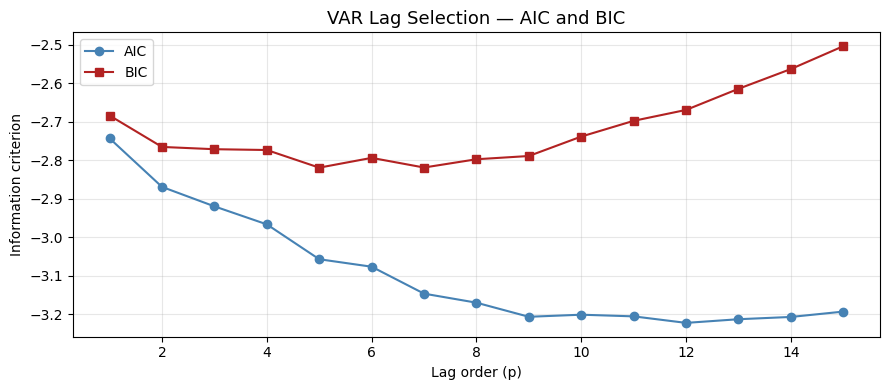


Selected lag by AIC: p = 12


In [34]:
model_var = VAR(df_var)
lag_order = model_var.select_order(maxlags=15)
print(lag_order.summary())

# Plot AIC/BIC vs lag
criteria = pd.DataFrame({
    "AIC": [model_var.fit(p).aic for p in range(1, 16)],
    "BIC": [model_var.fit(p).bic for p in range(1, 16)],
}, index=range(1, 16))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(criteria.index, criteria["AIC"], marker="o", label="AIC", color="steelblue")
ax.plot(criteria.index, criteria["BIC"], marker="s", label="BIC", color="firebrick")
ax.set_xlabel("Lag order (p)")
ax.set_ylabel("Information criterion")
ax.set_title("VAR Lag Selection — AIC and BIC", fontsize=13)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{VAR_DIR}/var_lag_selection.png", dpi=150)
plt.show()

best_p = int(lag_order.aic)
print(f"\nSelected lag by AIC: p = {best_p}")


In [35]:
best_p = int(VAR(df_var).select_order(maxlags=15).aic)
res_var = VAR(df_var).fit(best_p)
print(res_var.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 07, Apr, 2026
Time:                     14:33:14
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -2.66973
Nobs:                     981.000    HQIC:                  -3.01244
Log likelihood:          -2484.12    FPE:                  0.0398450
AIC:                     -3.22287    Det(Omega_mle):       0.0356564
--------------------------------------------------------------------
Results for equation tweets
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const               1.190418         1.058271            1.125           0.261
L1.tweets           0.143009         0.032219            4.439           0.000
L1.returns       -148.029064        66.081813           -2.240     

GRANGER CAUSALITY TESTS  (H0: X does NOT Granger-cause Y)
tweets → returns           F=  1.161  p=0.3054  ns
tweets → vix               F=  2.322  p=0.0060  ***
returns → tweets           F=  1.252  p=0.2406  ns
vix → tweets               F=  0.701  p=0.7517  ns
returns → vix              F=  3.049  p=0.0003  ***
vix → returns              F=  7.768  p=0.0000  ***


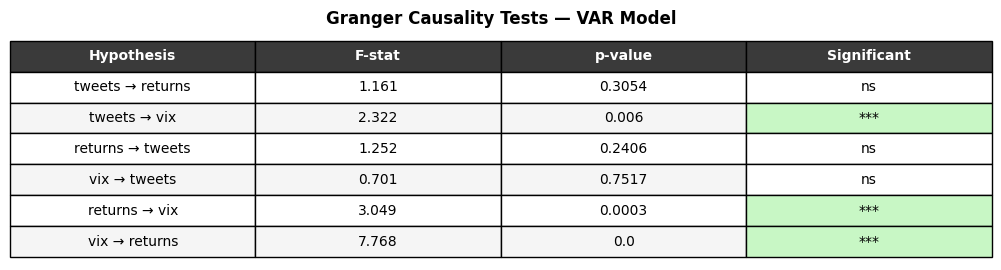

In [36]:
print("=" * 60)
print("GRANGER CAUSALITY TESTS  (H0: X does NOT Granger-cause Y)")
print("=" * 60)

pairs = [
    ("tweets → returns", "returns", ["tweets"]),
    ("tweets → vix",     "vix",     ["tweets"]),
    ("returns → tweets", "tweets",  ["returns"]),
    ("vix → tweets",     "tweets",  ["vix"]),
    ("returns → vix",    "vix",     ["returns"]),
    ("vix → returns",    "returns", ["vix"]),
]

gc_rows = []
for label, caused, causing in pairs:
    test = res_var.test_causality(caused, causing, kind="f")
    pval = test.pvalue
    sig  = "***" if pval < 0.01 else ("*" if pval < 0.05 else "ns")
    gc_rows.append({"Hypothesis": label,
                    "F-stat": round(test.test_statistic, 3),
                    "p-value": round(pval, 4),
                    "Significant": sig})
    print(f"{label:25s}  F={test.test_statistic:7.3f}  p={pval:.4f}  {sig}")

gc_df = pd.DataFrame(gc_rows)

fig, ax = plt.subplots(figsize=(10, 2.8))
ax.axis("off")
tbl = ax.table(cellText=gc_df.values, colLabels=gc_df.columns,
               cellLoc="center", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.1, 1.8)
for j in range(len(gc_df.columns)):
    tbl[0, j].set_facecolor("#3a3a3a")
    tbl[0, j].set_text_props(color="white", fontweight="bold")
for i in range(1, len(gc_rows) + 1):
    for j in range(len(gc_df.columns)):
        tbl[i, j].set_facecolor("#f5f5f5" if i % 2 == 0 else "white")
    sig_val = gc_df.iloc[i-1]["Significant"]
    col = "#c8f7c5" if sig_val != "ns" else "white"
    tbl[i, len(gc_df.columns)-1].set_facecolor(col)
ax.set_title("Granger Causality Tests — VAR Model", fontsize=12, fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig(f"{VAR_DIR}/granger_causality.png", dpi=150, bbox_inches="tight")
plt.show()


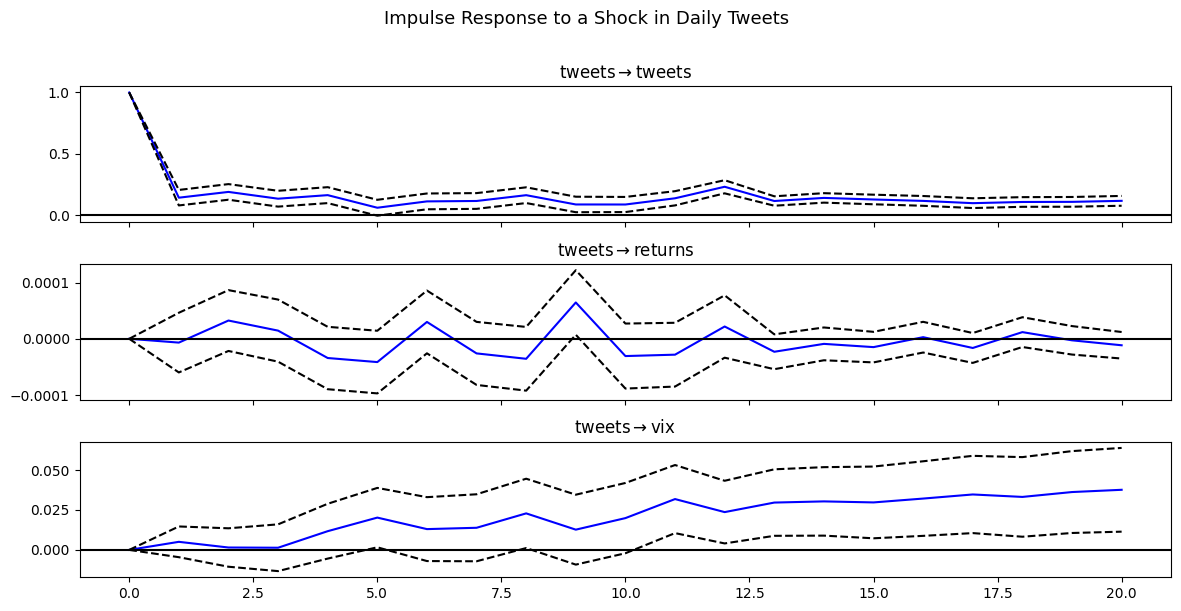

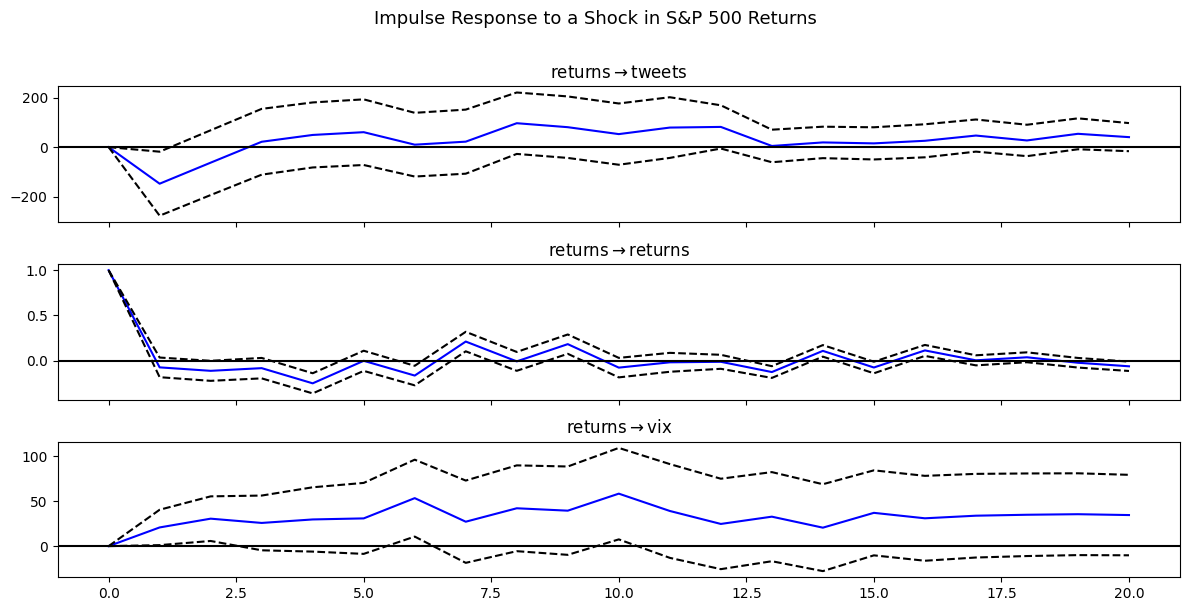

In [37]:
irf = res_var.irf(periods=20)

fig = irf.plot(impulse="tweets", figsize=(12, 6),
               subplot_params={"hspace": 0.5})
fig.suptitle("Impulse Response to a Shock in Daily Tweets", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{VAR_DIR}/irf_tweets_shock.png", dpi=150, bbox_inches="tight")
plt.show()

fig2 = irf.plot(impulse="returns", figsize=(12, 6),
                subplot_params={"hspace": 0.5})
fig2.suptitle("Impulse Response to a Shock in S&P 500 Returns", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{VAR_DIR}/irf_returns_shock.png", dpi=150, bbox_inches="tight")
plt.show()


In [38]:
wb = res_var.test_whiteness(nlags=20)
print("Whiteness test (H0: no autocorrelation in residuals):")
print(f"  chi2 = {wb.test_statistic:.3f},  p = {wb.pvalue:.4f}",
      "→ OK" if wb.pvalue > 0.05 else "→ autocorrelation remains")


Whiteness test (H0: no autocorrelation in residuals):
  chi2 = 146.488,  p = 0.0000 → autocorrelation remains


---
## 11. Cointegration Tests

In [39]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM

COINT_DIR = f"{SAVE_DIR}/../cointegration"
os.makedirs(COINT_DIR, exist_ok=True)

# Both SP500 Close and VIX are I(1) (unit root confirmed)
# Test cointegration between them + tweets in levels
df_levels = pd.DataFrame({
    "sp500": stock["SP500_Close"],
    "vix":   stock["VIX_Close"],
}).dropna()

print("Cointegration dataset:", df_levels.shape)
print(df_levels.head(3))


Cointegration dataset: (999, 2)
                  sp500    vix
date                          
2017-01-20  2271.310059  11.54
2017-01-23  2265.199951  11.77
2017-01-24  2280.070068  11.07


Johansen Cointegration Test
Trace statistics:
  r=0: stat=30.316  CV5%=15.494  Reject H0
  r=1: stat=0.223  CV5%=3.841  Fail to reject

Max-Eigenvalue statistics:
  r=0: stat=30.093  CV5%=14.264  Reject H0
  r=1: stat=0.223  CV5%=3.841  Fail to reject

Eigenvectors (cointegration vectors):
            0       1
sp500  0.0020 -0.0024
vix   -0.0978 -0.0468


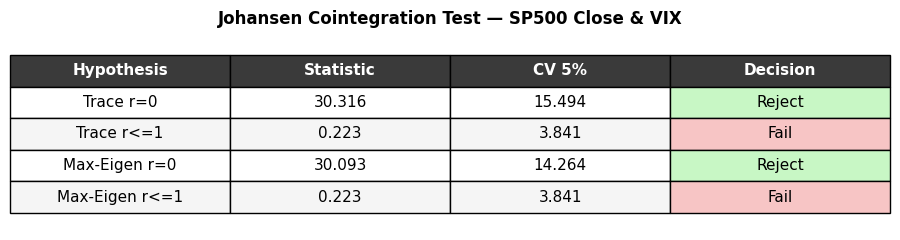

In [40]:
# Johansen test — det_order=0 (constant in CE), k_ar_diff=1
joh = coint_johansen(df_levels, det_order=0, k_ar_diff=1)

print("Johansen Cointegration Test")
print("="*55)
print("Trace statistics:")
print(f"  r=0: stat={joh.lr1[0]:.3f}  CV5%={joh.cvt[0,1]:.3f}  {'Reject H0' if joh.lr1[0]>joh.cvt[0,1] else 'Fail to reject'}")
print(f"  r=1: stat={joh.lr1[1]:.3f}  CV5%={joh.cvt[1,1]:.3f}  {'Reject H0' if joh.lr1[1]>joh.cvt[1,1] else 'Fail to reject'}")
print("\nMax-Eigenvalue statistics:")
print(f"  r=0: stat={joh.lr2[0]:.3f}  CV5%={joh.cvm[0,1]:.3f}  {'Reject H0' if joh.lr2[0]>joh.cvm[0,1] else 'Fail to reject'}")
print(f"  r=1: stat={joh.lr2[1]:.3f}  CV5%={joh.cvm[1,1]:.3f}  {'Reject H0' if joh.lr2[1]>joh.cvm[1,1] else 'Fail to reject'}")
print("\nEigenvectors (cointegration vectors):")
print(pd.DataFrame(joh.evec, index=df_levels.columns).round(4))

# Build summary table
rows_j = [
    ["Trace r=0",        f"{joh.lr1[0]:.3f}", f"{joh.cvt[0,1]:.3f}",
     "Reject" if joh.lr1[0] > joh.cvt[0,1] else "Fail"],
    ["Trace r<=1",       f"{joh.lr1[1]:.3f}", f"{joh.cvt[1,1]:.3f}",
     "Reject" if joh.lr1[1] > joh.cvt[1,1] else "Fail"],
    ["Max-Eigen r=0",    f"{joh.lr2[0]:.3f}", f"{joh.cvm[0,1]:.3f}",
     "Reject" if joh.lr2[0] > joh.cvm[0,1] else "Fail"],
    ["Max-Eigen r<=1",   f"{joh.lr2[1]:.3f}", f"{joh.cvm[1,1]:.3f}",
     "Reject" if joh.lr2[1] > joh.cvm[1,1] else "Fail"],
]
joh_df = pd.DataFrame(rows_j, columns=["Hypothesis", "Statistic", "CV 5%", "Decision"])

fig, ax = plt.subplots(figsize=(9, 2.5))
ax.axis("off")
tbl = ax.table(cellText=joh_df.values, colLabels=joh_df.columns,
               cellLoc="center", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.1, 1.9)
for j in range(len(joh_df.columns)):
    tbl[0, j].set_facecolor("#3a3a3a")
    tbl[0, j].set_text_props(color="white", fontweight="bold")
for i in range(1, len(rows_j) + 1):
    for j in range(len(joh_df.columns)):
        tbl[i, j].set_facecolor("#f5f5f5" if i % 2 == 0 else "white")
    dec = joh_df.iloc[i-1]["Decision"]
    tbl[i, len(joh_df.columns)-1].set_facecolor(
        "#c8f7c5" if dec == "Reject" else "#f7c5c5")
ax.set_title("Johansen Cointegration Test — SP500 Close & VIX", fontsize=12,
             fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig(f"{COINT_DIR}/johansen_table.png", dpi=150, bbox_inches="tight")
plt.show()


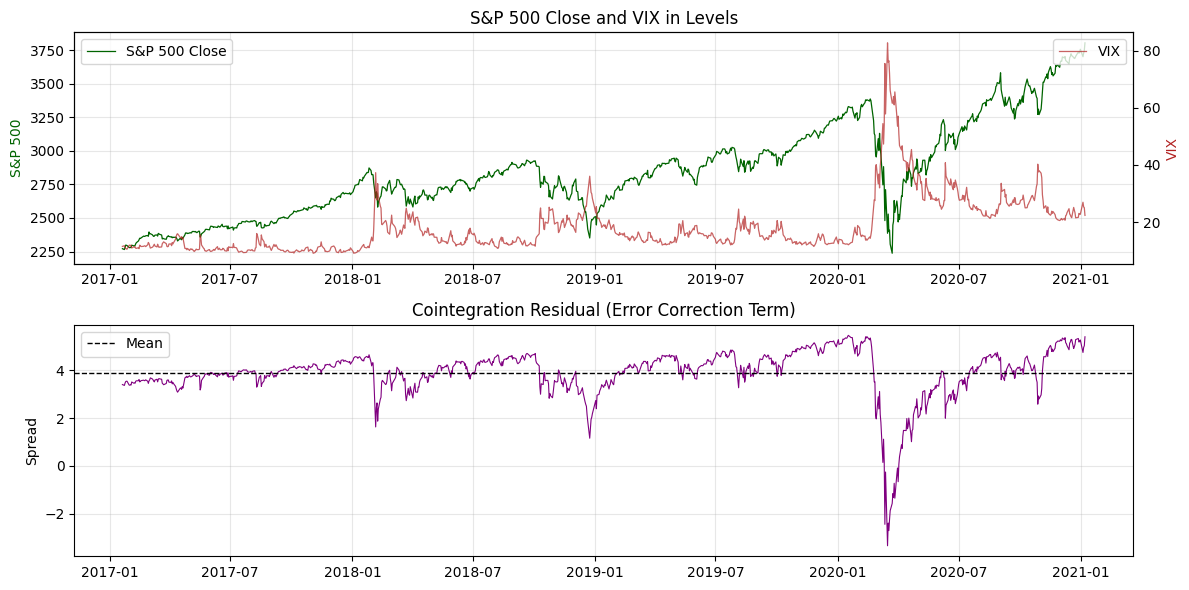

In [41]:
# Normalize eigenvector
beta = joh.evec[:, 0]
spread = df_levels @ beta

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(df_levels.index, df_levels["sp500"], color="darkgreen", linewidth=0.9,
             label="S&P 500 Close")
ax2 = axes[0].twinx()
ax2.plot(df_levels.index, df_levels["vix"], color="firebrick", linewidth=0.9,
         alpha=0.7, label="VIX")
axes[0].set_title("S&P 500 Close and VIX in Levels", fontsize=12)
axes[0].set_ylabel("S&P 500", color="darkgreen")
ax2.set_ylabel("VIX", color="firebrick")
axes[0].legend(loc="upper left"); ax2.legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

axes[1].plot(spread.index, spread, color="purple", linewidth=0.8)
axes[1].axhline(spread.mean(), color="black", linestyle="--", linewidth=1, label="Mean")
axes[1].set_title("Cointegration Residual (Error Correction Term)", fontsize=12)
axes[1].set_ylabel("Spread")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{COINT_DIR}/cointegration_spread.png", dpi=150)
plt.show()


---
## 12. VECM — Vector Error Correction Model

In [42]:
vecm_res = VECM(df_levels, k_ar_diff=1, coint_rank=1, deterministic="co").fit()
print(vecm_res.summary())


Det. terms outside the coint. relation & lagged endog. parameters for equation sp500
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.5129      4.449      0.790      0.430      -5.207      12.233
L1.sp500      -0.1240      0.053     -2.355      0.019      -0.227      -0.021
L1.vix         2.0593      0.841      2.449      0.014       0.411       3.707
Det. terms outside the coint. relation & lagged endog. parameters for equation vix
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9640      0.271     -3.560      0.000      -1.495      -0.433
L1.sp500       0.0082      0.003      2.572      0.010       0.002       0.015
L1.vix        -0.1377      0.051     -2.692      0.007      -0.238      -0.037
               Loading coefficients (alpha

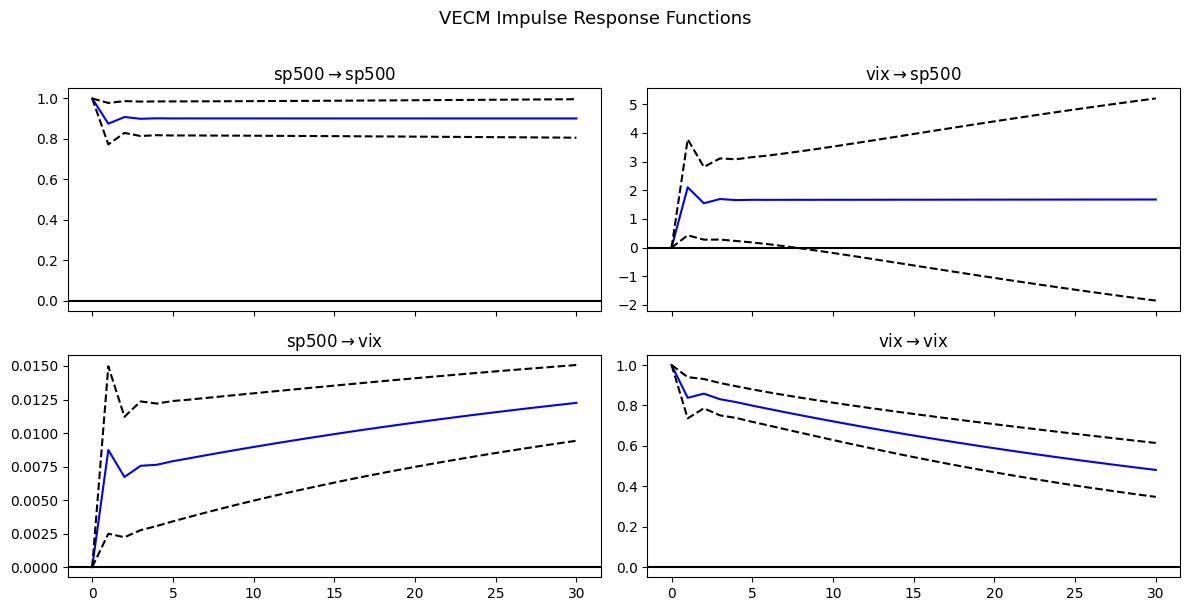

In [43]:
irf_vecm = vecm_res.irf(periods=30)
fig = irf_vecm.plot(figsize=(12, 6), subplot_params={"hspace": 0.5})
fig.suptitle("VECM Impulse Response Functions", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{COINT_DIR}/vecm_irf.png", dpi=150, bbox_inches="tight")
plt.show()


In [44]:
# Extract key VECM parameters
alpha = vecm_res.alpha   # adjustment speeds
beta  = vecm_res.beta    # cointegrating vector
print("Cointegrating vector (beta):")
print(pd.DataFrame(beta, index=df_levels.columns, columns=["beta"]).round(4))
print("\nAdjustment coefficients (alpha):")
print(pd.DataFrame(alpha, index=df_levels.columns, columns=["alpha"]).round(4))


Cointegrating vector (beta):
          beta
sp500   1.0000
vix   -49.0588

Adjustment coefficients (alpha):
        alpha
sp500 -0.0009
vix    0.0005
